- Zehra Ugurlu
- N01749401

#### Real-life relevance of the problem

For this project, the Iris dataset was used as the real-world data source. The Iris dataset is a well-known, publicly available dataset originally introduced by Ronald Fisher. It contains 150 samples of iris flowers, each described by four numerical features:
- Sepal length
-  Sepal width
-  Petal length
-  Petal width

It represents a typical tabular measurement dataset, similar to those used in real-world domains such as:
- Medical records
- Biological measurements
- Sensor data
- Financial features
In many of these domains, data is often:
- Limited in quantity
- Sensitive or private
- Expensive or difficult to collect
GANs can be used in such scenarios to generate synthetic data that follows the same statistical distribution as the original dataset.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
np.random.seed(7)
tf.random.set_seed(7)

OUT_DIR = "gan_iris_2d_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
iris = load_iris()
X = iris.data.astype(np.float32) 

X_std = StandardScaler().fit_transform(X)
X_2d = PCA(n_components=2, random_state=7).fit_transform(X_std).astype(np.float32)

max_abs = np.max(np.abs(X_2d), axis=0)
X_2d = (X_2d / max_abs).astype(np.float32)

real_data = X_2d

In [4]:
BATCH_SIZE = 64
ds = tf.data.Dataset.from_tensor_slices(real_data)
ds = ds.shuffle(512, seed=7, reshuffle_each_iteration=True).batch(BATCH_SIZE, drop_remainder=True)

In [5]:
noise_dim = 8

def make_generator():
    return tf.keras.Sequential([
        layers.Input(shape=(noise_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(2, activation="tanh")
    ], name="Generator")

def make_discriminator():
    return tf.keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)  # logits
    ], name="Discriminator")

generator = make_generator()
discriminator = make_discriminator()

In [6]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_logits):
    return bce(tf.ones_like(fake_logits), fake_logits)

def discriminator_loss(real_logits, fake_logits):
    real_loss = bce(tf.ones_like(real_logits), real_logits)
    fake_loss = bce(tf.zeros_like(fake_logits), fake_logits)
    return real_loss + fake_loss

gen_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [7]:
@tf.function
def train_step(real_batch):
    bs = tf.shape(real_batch)[0]
    noise = tf.random.normal([bs, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_batch = generator(noise, training=True)

        real_logits = discriminator(real_batch, training=True)
        fake_logits = discriminator(fake_batch, training=True)

        g_loss = generator_loss(fake_logits)
        d_loss = discriminator_loss(real_logits, fake_logits)

    gen_grads = gen_tape.gradient(g_loss, generator.trainable_variables)
    disc_grads = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return g_loss, d_loss

In [8]:
def save_scatter(epoch, n_fake=2000):
    z = tf.random.normal([n_fake, noise_dim])
    fake = generator(z, training=False).numpy()

    plt.figure(figsize=(7, 6))
    plt.scatter(real_data[:, 0], real_data[:, 1], s=18, alpha=0.85, label="Real (Iris PCA->2D)")
    plt.scatter(fake[:, 0], fake[:, 1], s=10, alpha=0.35, label="Generated")
    plt.title(f"Real vs Generated - Epoch {epoch}")
    plt.xlabel("PC1 (scaled)")
    plt.ylabel("PC2 (scaled)")
    plt.legend()
    plt.tight_layout()
    plt.show()

2026-02-12 19:19:39.836040: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 19:19:39.838109: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 19:19:39.841609: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 19:19:39.847488: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 19:19:39.860855: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 19:19:39.884485: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-12 19:19:39.933716: I tensorflow/core/framework/local_rendezvous.cc:407] L

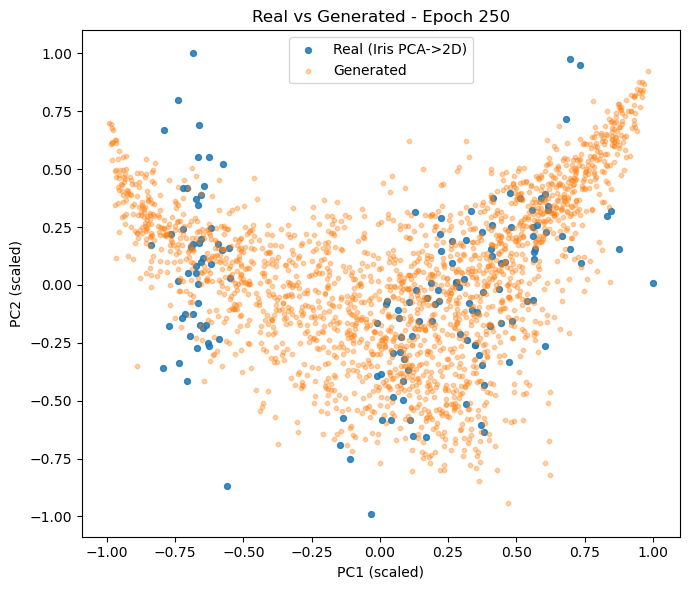

Epoch  250 | D loss: 1.3737 | G loss: 0.6990


2026-02-12 19:19:40.363123: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


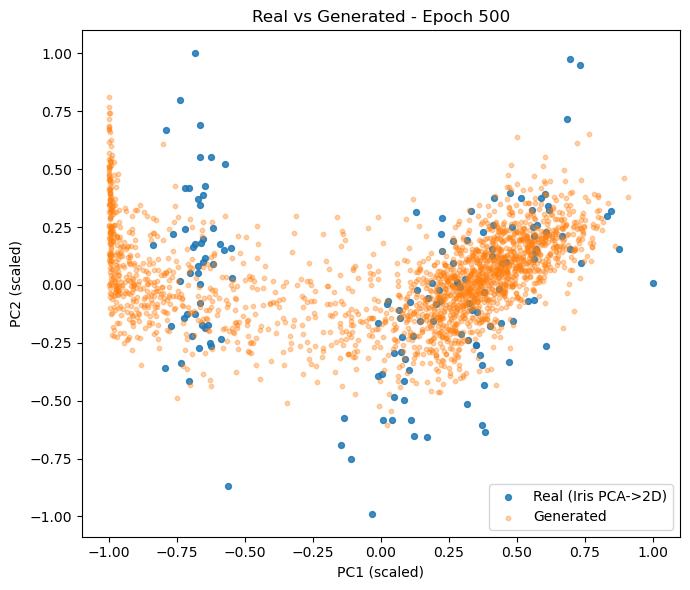

Epoch  500 | D loss: 1.3760 | G loss: 0.7026


2026-02-12 19:19:40.843339: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


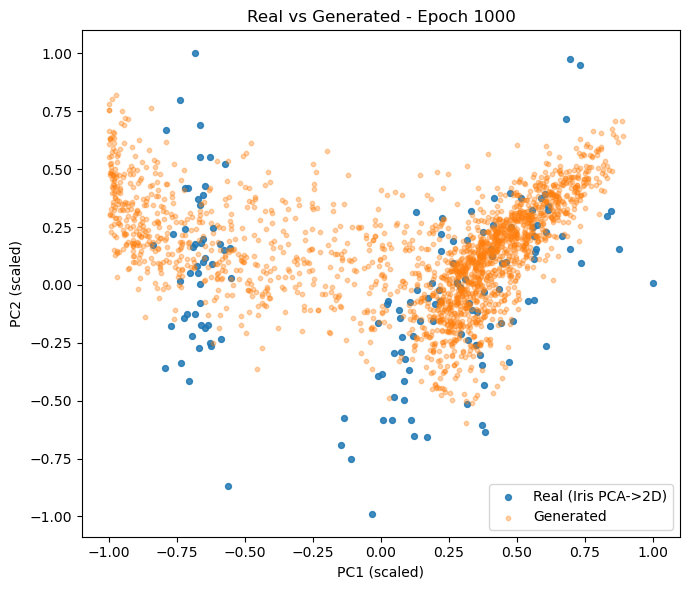

Epoch 1000 | D loss: 1.3680 | G loss: 0.6799


In [9]:
epochs = 1000
snapshots = {0, 250,500,1000}

g_hist, d_hist = [], []

for epoch in range(1, epochs + 1):
    g_losses, d_losses = [], []

    for real_batch in ds:
        g_loss, d_loss = train_step(real_batch) 
        g_losses.append(g_loss.numpy())
        d_losses.append(d_loss.numpy())

    g_epoch = float(np.mean(g_losses))
    d_epoch = float(np.mean(d_losses))
    g_hist.append(g_epoch)
    d_hist.append(d_epoch)

    if epoch in snapshots:
        save_scatter(epoch)
        print(f"Epoch {epoch:4d} | D loss: {d_epoch:.4f} | G loss: {g_epoch:.4f}")



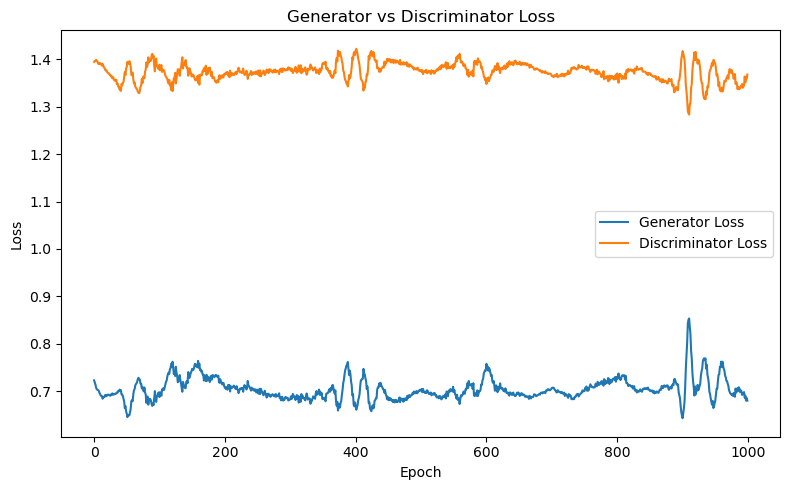

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(g_hist, label="Generator Loss")
plt.plot(d_hist, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator vs Discriminator Loss")
plt.legend()
plt.tight_layout()
plt.show()

The discriminator and generator losses level off at about 1.3 and 0.7, respectively. This shows that the training process is steady and neither network dominates the other. As a result, it seems that the GAN has achieved a balanced adversarial state.